# Ai Loan Approval Project

#### Business Problem: The main objective of this project is to predict whether a loan applicant is eligible for loan approval based on factors such as income, loan amount, credit history, and employment details.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter('ignore')

In [5]:
df=pd.read_csv(r'C:\Users\DELL\OneDrive\Desktop\loan_train.csv')
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
df.shape

(614, 13)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [8]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [10]:
# Checking for NULL values:

df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [11]:
# Filling the NULL values:

# Categorical columns
df['Gender'].fillna(df['Gender'].mode()[0],inplace=True)
df['Married'].fillna(df['Married'].mode()[0],inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0],inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0],inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0],inplace=True)

#Numerical columns:
df['LoanAmount'].fillna(df['LoanAmount'].mean(),inplace=True)
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mean(),inplace=True)

In [12]:
# Again checking for NULL values:
df.isna().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
# Checking for Duplicate values:

df.duplicated().sum()

0

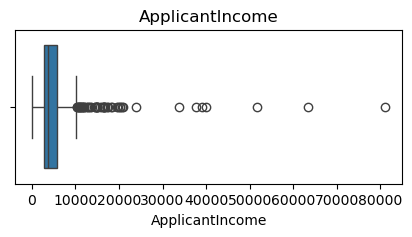

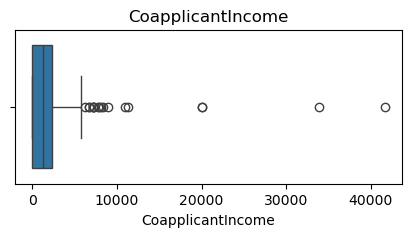

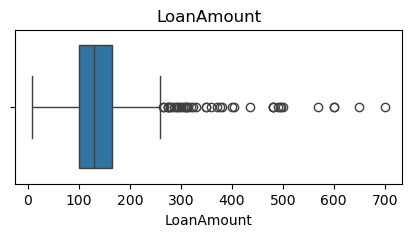

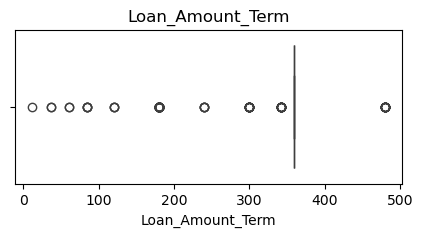

In [14]:
# Checking for Outliers in the dataset:

num_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount',
            'Loan_Amount_Term']

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [15]:
# Removing the outliers:

df['ApplicantIncome']=np.log(df['ApplicantIncome'])
df['CoapplicantIncome']=np.log(df['CoapplicantIncome'])
df['LoanAmount']=np.log(df['LoanAmount'])

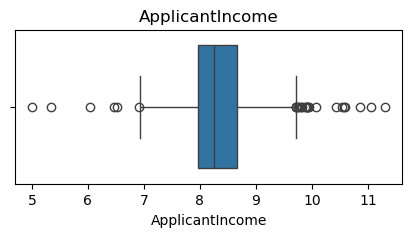

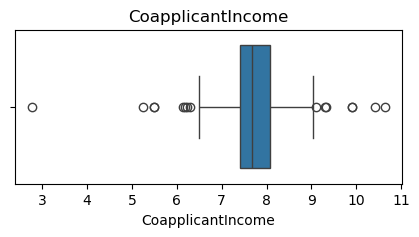

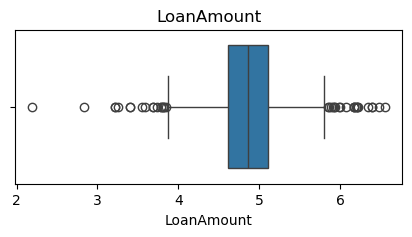

In [16]:
# Rechecking for Outliers:

num_cols = ['ApplicantIncome',
            'CoapplicantIncome',
            'LoanAmount']

for col in num_cols:
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [17]:
# Checking text columns:
df.select_dtypes(include='object').columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [18]:
# Applying Label Encoding:

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for cols in df.select_dtypes(include='object').columns:
    df[cols]=le.fit_transform(df[cols])

In [19]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,0,0,8.674026,-inf,4.986426,360.0,1.0,2,1
1,1,1,1,1,0,0,8.430109,7.318540,4.852030,360.0,1.0,0,0
2,2,1,1,0,0,1,8.006368,-inf,4.189655,360.0,1.0,2,1
3,3,1,1,0,1,0,7.856707,7.765569,4.787492,360.0,1.0,2,1
4,4,1,0,0,0,0,8.699515,-inf,4.948760,360.0,1.0,2,1


In [20]:
# Feature Selection:

x=df.drop('Loan_Status',axis=1)
y=df['Loan_Status']

In [21]:
x = x.replace([np.inf, -np.inf], np.nan)

In [22]:
x = x.fillna(x.mean(numeric_only=True))

In [23]:
# Train Test Split:

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=10)

In [24]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [25]:
# Training model:
# 1.Logistic Regression:

from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [26]:
# Predictions and Evaluation:

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 0.8126272912423625
TEST ACCURACY: 0.7967479674796748
CROSS VALIDATION: 0.809462881514061


In [27]:
# 2.Decision Tree:

from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=0)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=0)

In [28]:
# Evaluation
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 1.0
TEST ACCURACY: 0.6666666666666666
CROSS VALIDATION: 0.6774090363854459


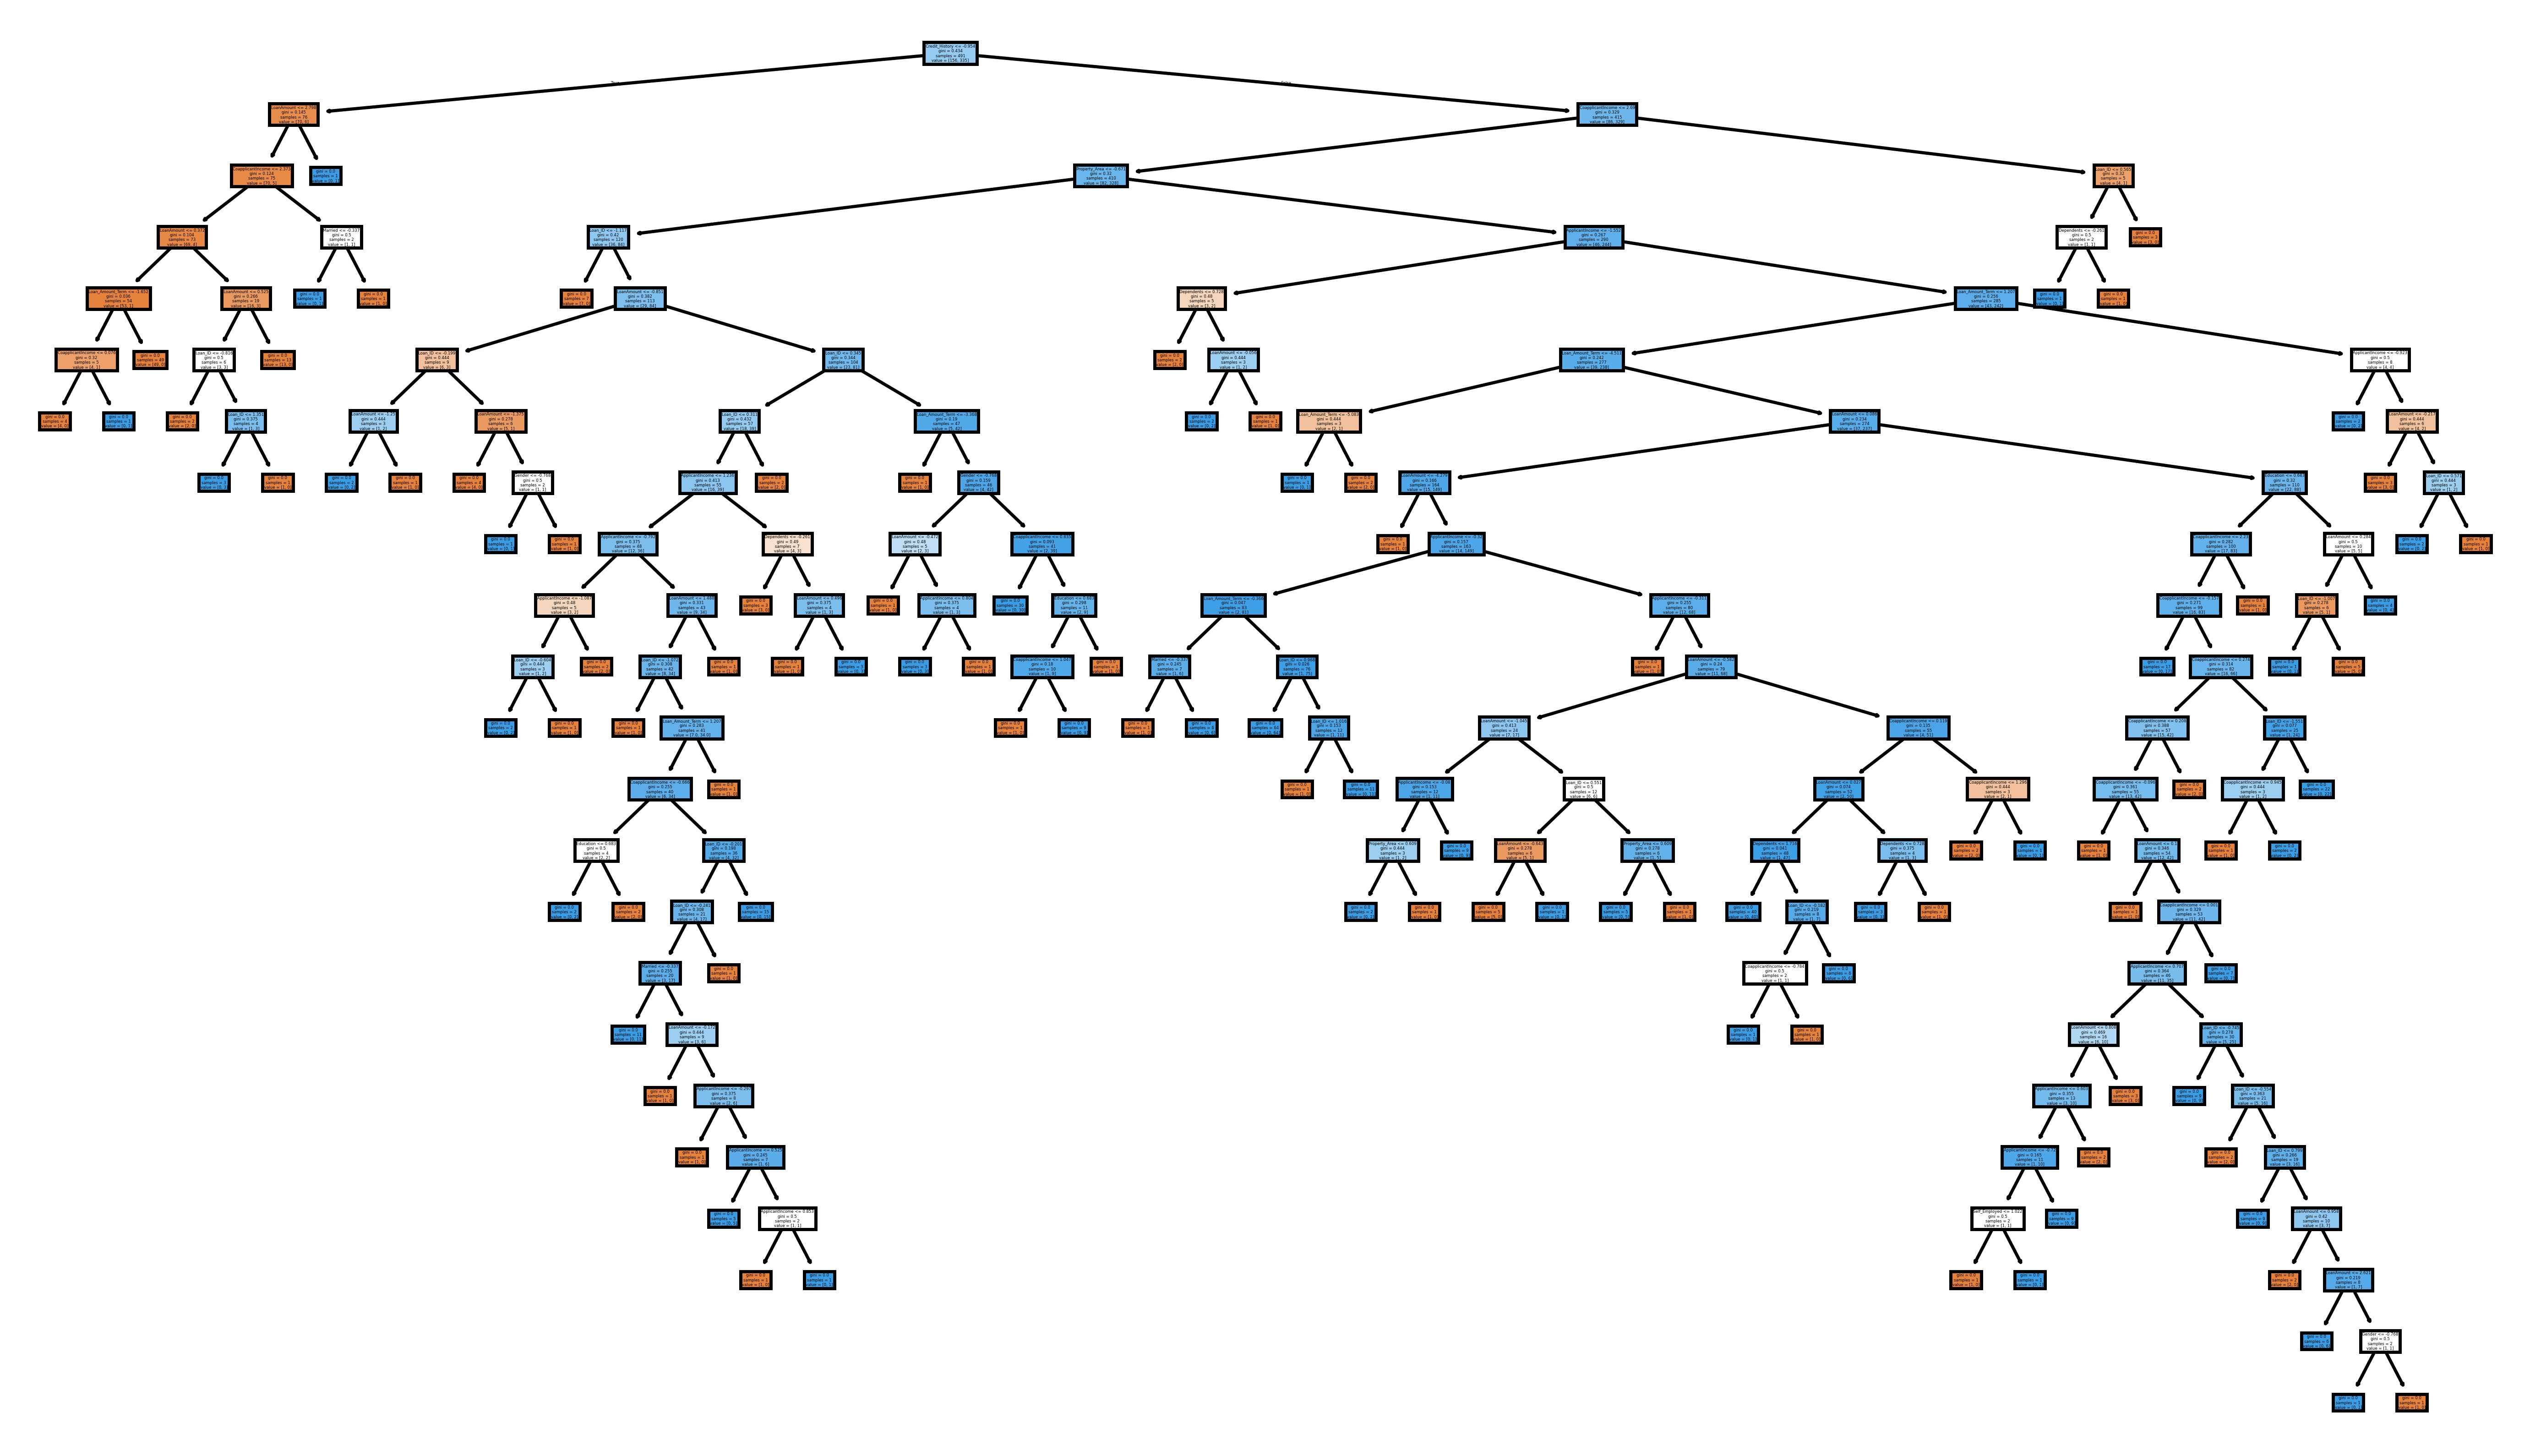

In [29]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8),dpi=500)
plot_tree(model,filled=True,feature_names=x.columns)
plt.show()

In [30]:
# Hyper Parameter Tunnning:

from sklearn.model_selection import GridSearchCV
estimator=DecisionTreeClassifier(random_state=0)
param_grid={'criterion':['gini','entropy'],'max_depth':[3,5,7,10]}
grid=GridSearchCV(estimator,param_grid,scoring='accuracy',cv=5)
grid.fit(x_train,y_train)
grid.best_params_

{'criterion': 'gini', 'max_depth': 3}

In [31]:
model=DecisionTreeClassifier(criterion='gini',max_depth=3,random_state=0)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=0)

In [32]:
# Evaluation
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 0.8207739307535642
TEST ACCURACY: 0.7967479674796748
CROSS VALIDATION: 0.8029321604691455


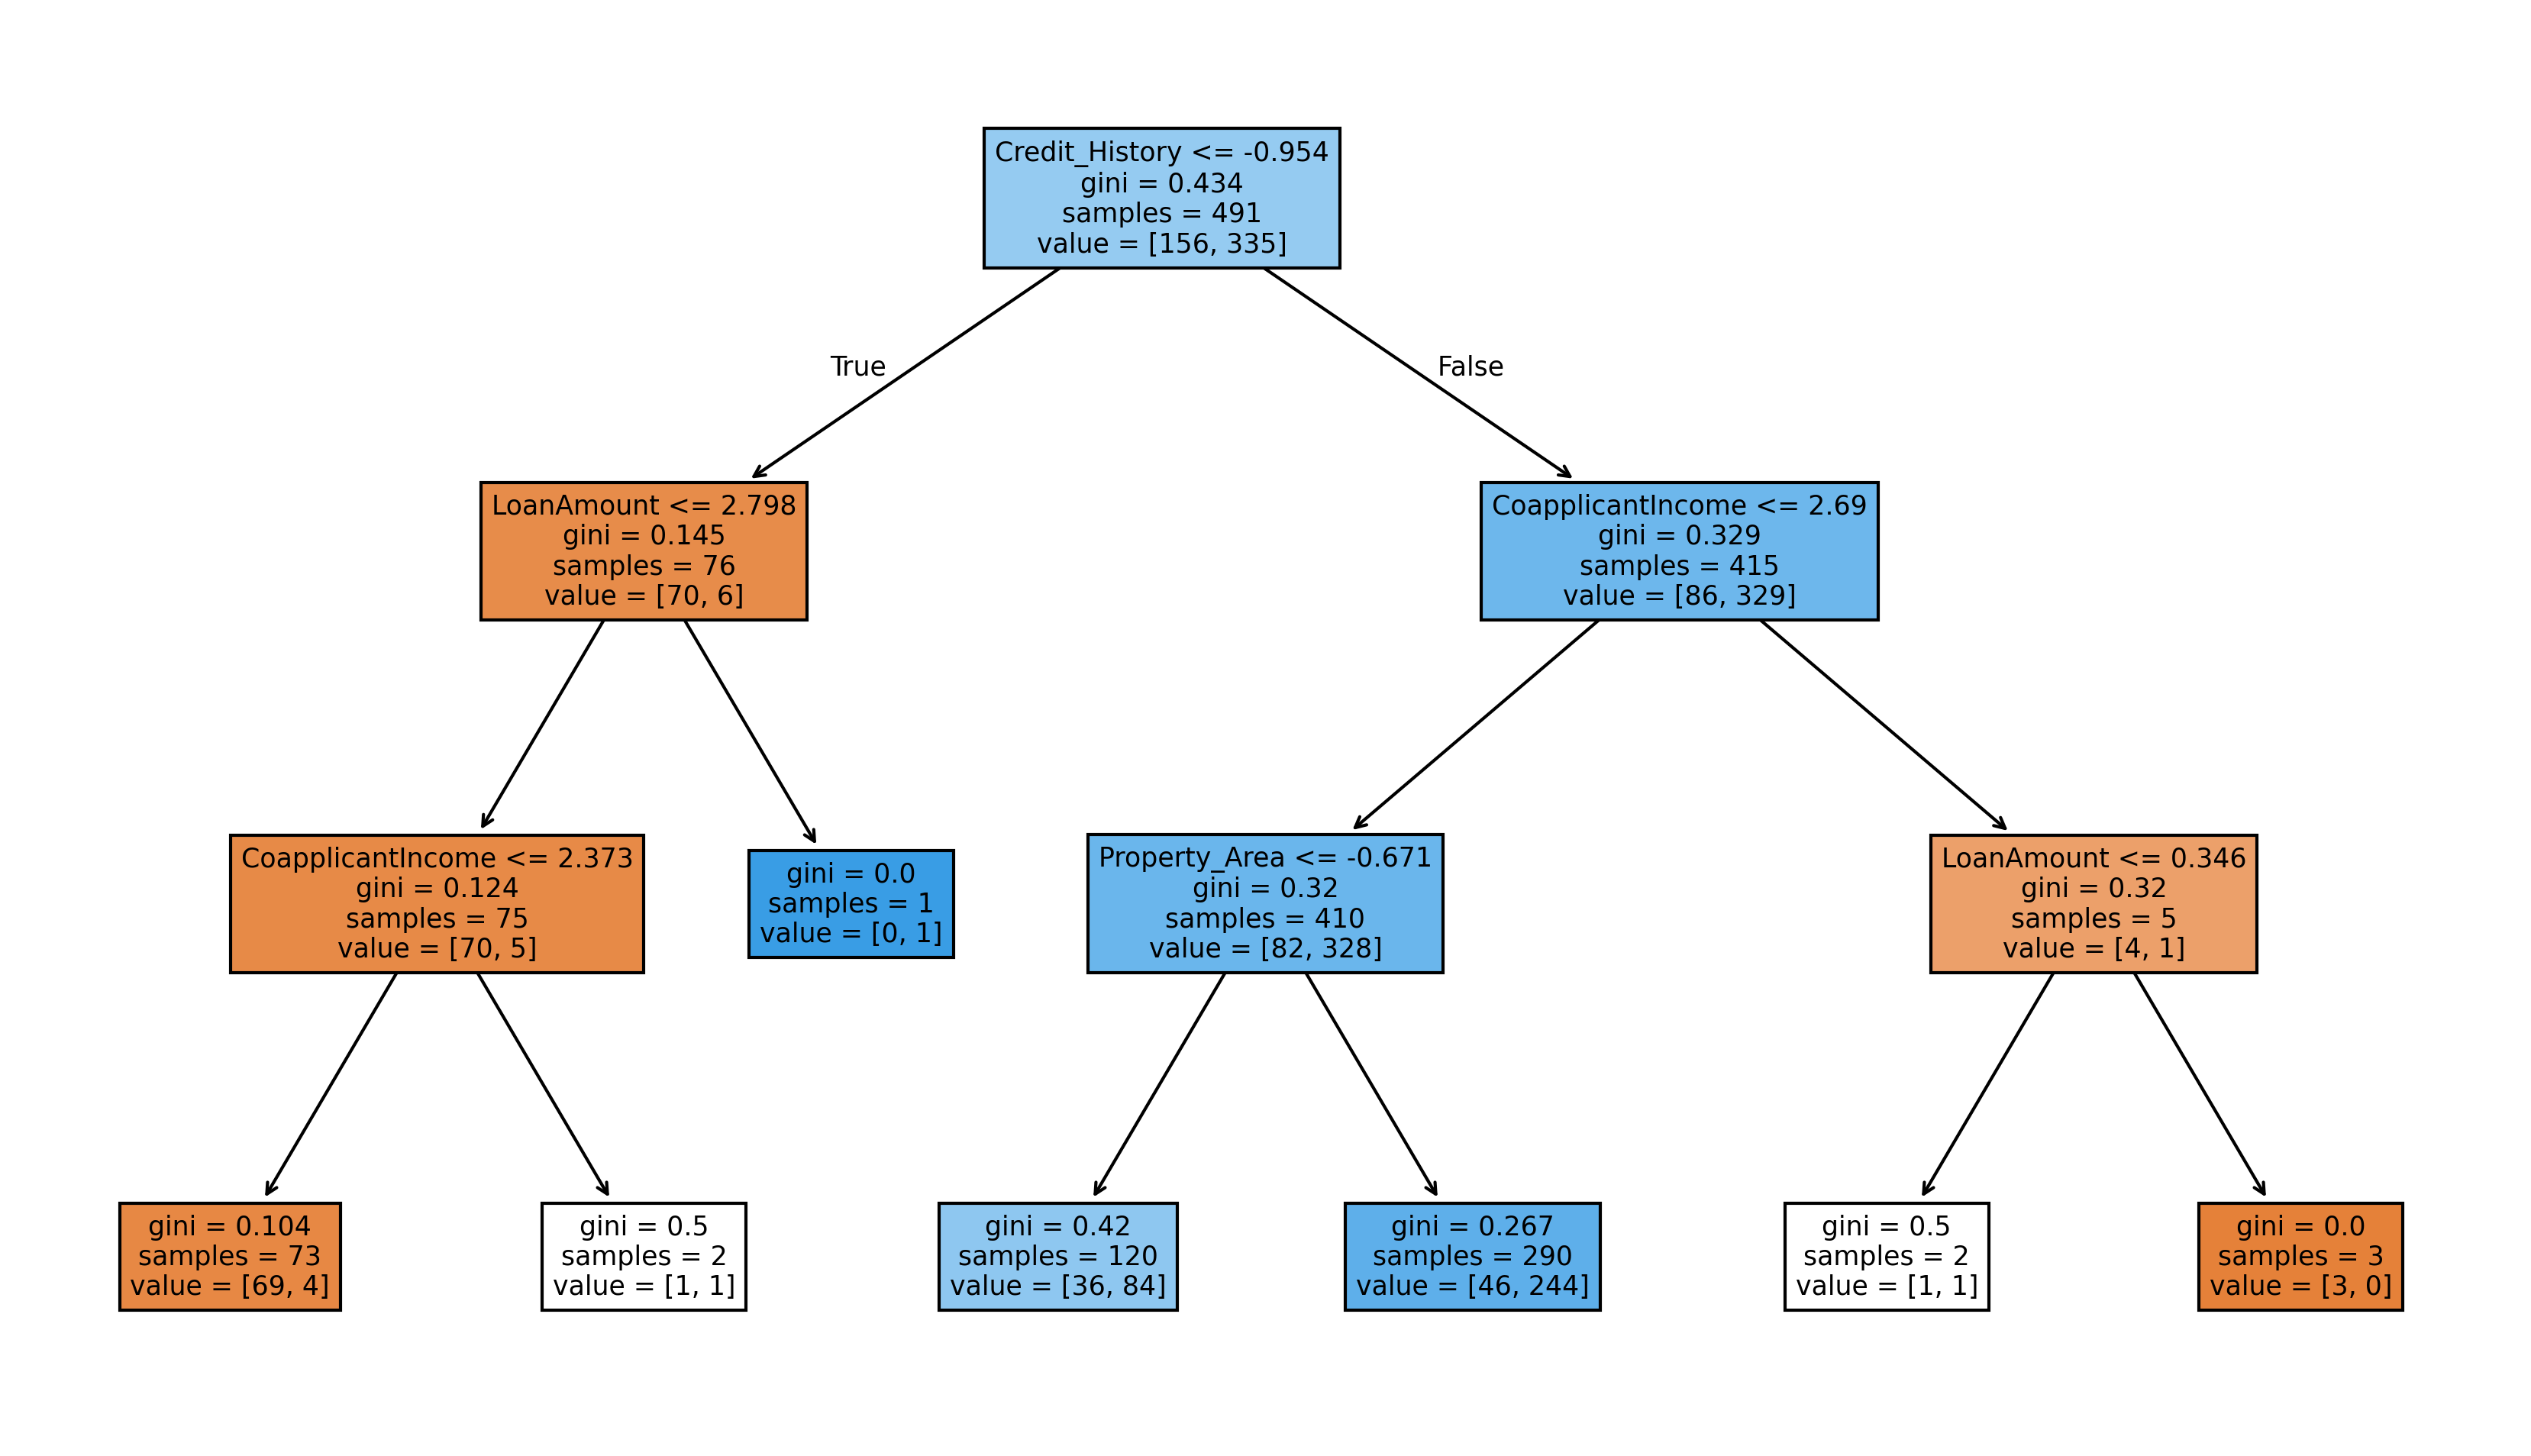

In [33]:
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8),dpi=300)
plot_tree(model,filled=True,feature_names=x.columns)
plt.show()

In [34]:
# 3.XG Boost:

from xgboost import XGBClassifier
model=XGBClassifier()
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [35]:
# Evaluation
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 1.0
TEST ACCURACY: 0.7723577235772358
CROSS VALIDATION: 0.7588831134212981


In [36]:
# Hyper Parameter Tunnning:
estimator=XGBClassifier()

param_grid={'n_estimators':[10,20,40,100],
            'max_depth':[3,4,5],
            'learning_rate':[0,0.15,0.3,0.5,1]}
grid=GridSearchCV(estimator,param_grid,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_


{'learning_rate': 0.15, 'max_depth': 3, 'n_estimators': 40}

In [37]:
model=XGBClassifier(learning_rate=0.15, max_depth=3,n_estimators= 40)
model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.15, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=40,
              n_jobs=None, num_parallel_tree=None, ...)

In [38]:
# Evaluation
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 0.845213849287169
TEST ACCURACY: 0.7886178861788617
CROSS VALIDATION: 0.7980940956950552


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, ypred_test))

              precision    recall  f1-score   support

           0       0.86      0.33      0.48        36
           1       0.78      0.98      0.87        87

    accuracy                           0.79       123
   macro avg       0.82      0.66      0.67       123
weighted avg       0.80      0.79      0.75       123



In [40]:
# Predicting the Loan Status for sample data:

model.predict([[1,1,0,0,0,5000,2000,150,360,1,2,0]])

array([1])

In [41]:
# 4.Random Forest:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train,y_train)

RandomForestClassifier()

In [42]:
# Evaluation
ypred_train=model.predict(x_train)
ypred_test=model.predict(x_test)

print("TRAIN ACCURACY:",accuracy_score(y_train,ypred_train))
print("TEST ACCURACY:",accuracy_score(y_test,ypred_test))
scores=cross_val_score(model,x,y,cv=5)
print("CROSS VALIDATION:",scores.mean())

TRAIN ACCURACY: 1.0
TEST ACCURACY: 0.8048780487804879
CROSS VALIDATION: 0.7784886045581766


##Report:
1.Loaded the data : there are total 614 rows and 13 columns.
2.Data Preprocessing : checked for null values and replaced them with mean (numeric values) and mode(text values) .
    -checked for duplicate values.
    -checked for +inf,-inf values and replaced them with null values and again filled the null values .
    -checked for the outliers and removed them using a simple log function.
3.Encoding : applied a simple Label Encoding technique - to convert text data to numeric data cause most of the data is in binary format.
4.Feature Selection : assigned columns as independent variables and dependent variables as x,y.
5.Train Test Split: assigned 80% of data as train data and 20% of data test data.
6.Feature Scalling: applied Standard Scalling ( makes Mean=0 and Standard devistion=1 ) to make all columns into a simillar range and normalize all the    columns such that there wont be any biasness.
7. a) Logistic Regression: trained the model ,made pedictions and evaluated the accuracy 
   got TRAIN ACCURACY: 0.8126272912423625
      TEST ACCURACY: 0.7967479674796748
      CROSS VALIDATION: 0.809462881514061              (it is a good model)

   b) Decision Tree: repeated the same process and got:
            TRAIN ACCURACY: 1.0
            TEST ACCURACY: 0.6666666666666666
            CROSS VALIDATION: 0.6774090363854459           (which is not a good model cause there is more than 5% difference btw train,test and cross                                                                validation)    
   -So, applied Hyper Prameter Tunning to get better accuracy
   -And again rebuild the model and got the accuracies:
            TRAIN ACCURACY: 0.8207739307535642
            TEST ACCURACY: 0.7967479674796748
            CROSS VALIDATION: 0.8029321604691455        (which is a good model cause there is less than 5% difference btw train,test and cross                                                                    validation) 
    -And again re-plotted the graph and we clearly see that the tree has minimized

   c) XG Boost: trained the model ,made pedictions and evaluated the accuracy
           TRAIN ACCURACY: 1.0
           TEST ACCURACY: 0.7723577235772358
           CROSS VALIDATION: 0.7588831134212981       (which is not a good model cause there is more than 5% difference btw train,test and cross                                                                validation)  
    -So, applied Hyper Prameter Tunning to get better accuracy
   -And again rebuild the model and got the accuracies:
           TRAIN ACCURACY: 0.845213849287169
           TEST ACCURACY: 0.7886178861788617
           CROSS VALIDATION: 0.7980940956950552      (which is a good model cause there is less than 5% difference btw train,test and cross                                                                    validation) 
    d) Random Forest: trained the model ,made pedictions and evaluated the accuracy
         TRAIN ACCURACY: 1.0
         TEST ACCURACY: 0.8048780487804879
         CROSS VALIDATION: 0.7784886045581766       (which is not a good model cause there is more than 5% difference btw train,test and cross                                                                validation)  
    